In [2]:
import pandas as pd

data = pd.read_csv("dataset2.csv")

print(data.head())

FileNotFoundError: [Errno 2] No such file or directory: 'dataset2.csv'

In [3]:
import pandas as pd

data = pd.read_csv("Mall_Customers.csv")

print(data.head())

FileNotFoundError: [Errno 2] No such file or directory: 'Mall_Customers.csv'

In [4]:
import os
print(os.getcwd())

C:\Users\Santhosh


In [5]:
import os
print(os.listdir())

['.arduinoIDE', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.streamlit', '.vscode', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Customer_Segmentation.ipynb', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Mall_Customers.csv', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{6a8260b4-2ffd-11f1-9f45-005056c00008}.TM.blf', 'NTUSER.DAT{6a8260b4-2ffd-11f1-9f45-005056c00008}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{6a8260b4-2ffd-11f1-9f45-005056c00008}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'office 2024', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Videos']


In [6]:
import pandas as pd

data = pd.read_csv("Mall_Customers.csv")

print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [7]:
print(data.info())
print(data.describe())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000      

In [8]:
print(data.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


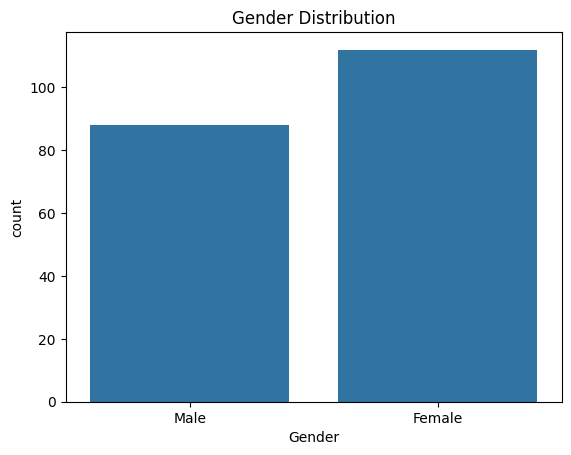

In [11]:
sns.countplot(x='Gender', data=data)

plt.title("Gender Distribution")

plt.show()

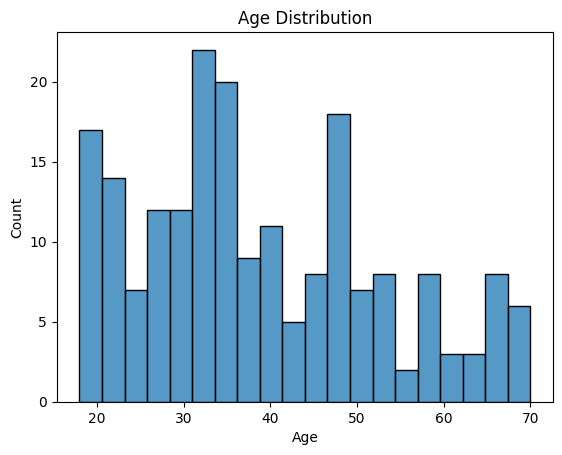

In [12]:
sns.histplot(data['Age'], bins=20)

plt.title("Age Distribution")

plt.show()

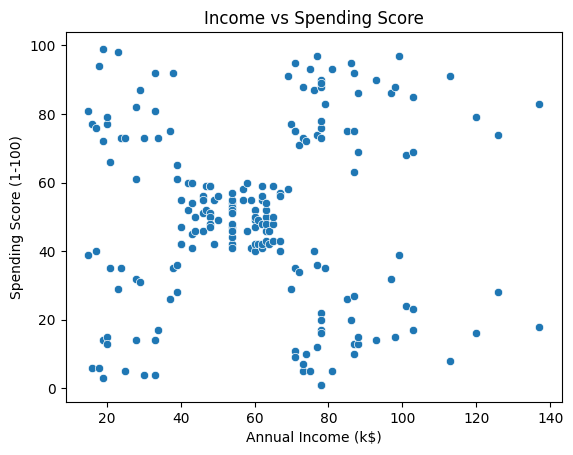

In [13]:

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=data
)

plt.title("Income vs Spending Score")

plt.show()

In [14]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


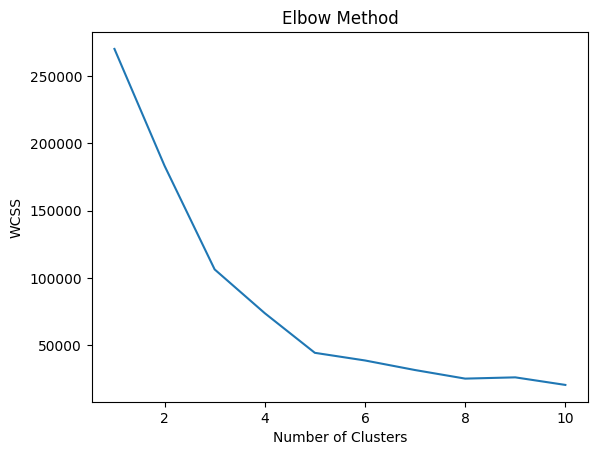

In [15]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [16]:
kmeans = KMeans(n_clusters=5, init='k-means++')

data['Cluster'] = kmeans.fit_predict(X)

print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        0  
2        4  
3        0  
4        4  


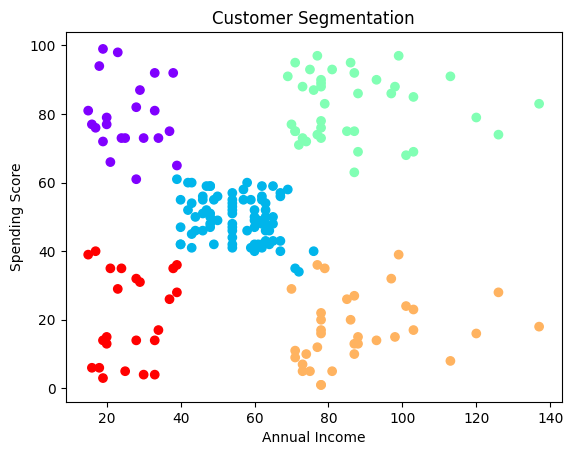

In [17]:
plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=data['Cluster'],
    cmap='rainbow'
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segmentation")

plt.show()

In [18]:
print(data.groupby('Cluster').mean())

TypeError: dtype 'str' does not support operation 'mean'

In [19]:
print(data.groupby('Cluster').mean(numeric_only=True))

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         23.090909  25.272727           25.727273               79.363636
1         86.320988  42.716049           55.296296               49.518519
2        162.000000  32.692308           86.538462               82.128205
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


In [20]:
data['Customer Type'] = data['Cluster'].map({
    0:'Premium Customers',
    1:'Budget Customers',
    2:'Regular Customers',
    3:'Impulse Buyers',
    4:'Careful Customers'
})

print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster      Customer Type  
0        4  Careful Customers  
1        0  Premium Customers  
2        4  Careful Customers  
3        0  Premium Customers  
4        4  Careful Customers  


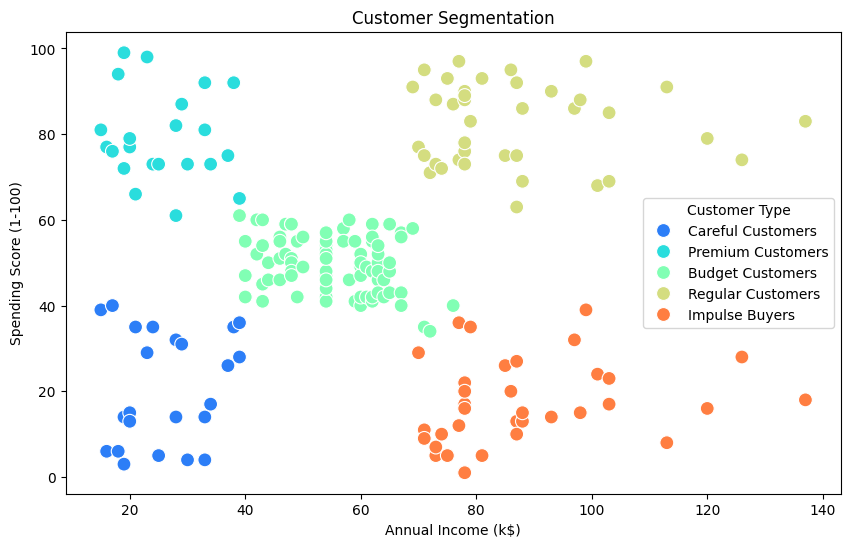

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Customer Type',
    data=data,
    palette='rainbow',
    s=100
)

plt.title("Customer Segmentation")

plt.show()

In [22]:
data.to_csv("Customer_Segmentation_Output.csv", index=False)

In [23]:
cluster_summary = data.groupby('Customer Type').mean(numeric_onlycluster_summary = data.groupby('Customer Type').mean(numeric_only=True)

print(cluster_summary)=True)

print(cluster_summary)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (184905201.py, line 1)

In [24]:
cluster_summary = data.groupby('Customer Type').mean(numeric_only=True)

print(cluster_summary)

                   CustomerID        Age  Annual Income (k$)  \
Customer Type                                                  
Budget Customers    86.320988  42.716049           55.296296   
Careful Customers   23.000000  45.217391           26.304348   
Impulse Buyers     164.371429  41.114286           88.200000   
Premium Customers   23.090909  25.272727           25.727273   
Regular Customers  162.000000  32.692308           86.538462   

                   Spending Score (1-100)  Cluster  
Customer Type                                       
Budget Customers                49.518519      1.0  
Careful Customers               20.913043      4.0  
Impulse Buyers                  17.114286      3.0  
Premium Customers               79.363636      0.0  
Regular Customers               82.128205      2.0  


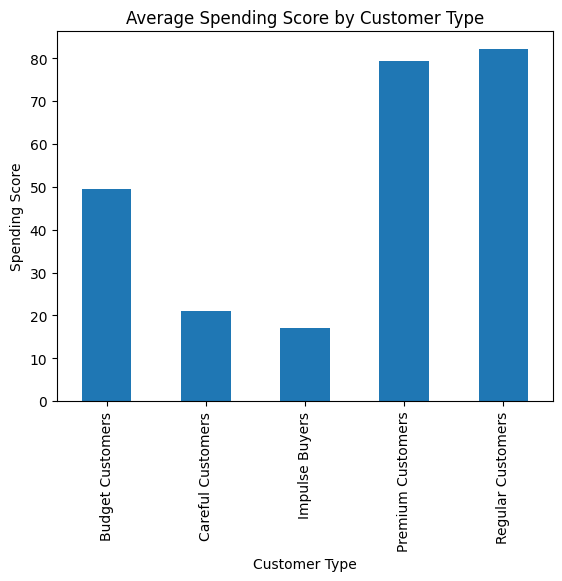

In [25]:
cluster_summary['Spending Score (1-100)'].plot(kind='bar')

plt.title("Average Spending Score by Customer Type")

plt.ylabel("Spending Score")

plt.show()

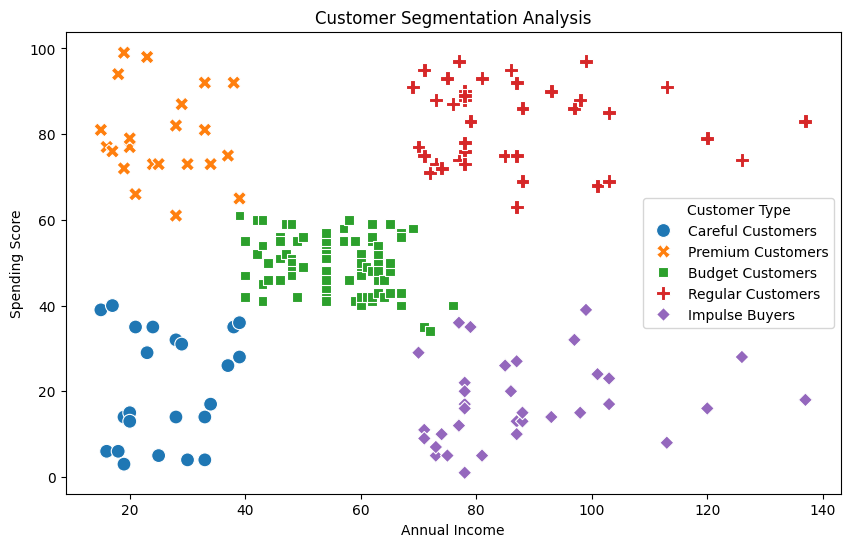

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Customer Type',
    style='Customer Type',
    data=data,
    s=100
)

plt.title("Customer Segmentation Analysis")

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")
plt.savefig("customer_segmentation_graph.png")

plt.show()

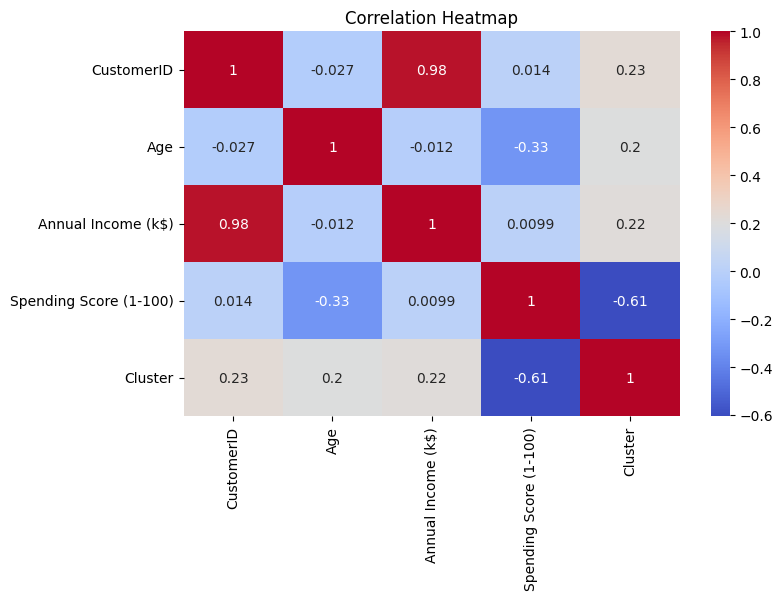

In [28]:
plt.figure(figsize=(8,5))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()